<a href="https://colab.research.google.com/github/Santiagolucgar/Tulum/blob/main/linear_regression_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.stats.api as sms
import statsmodels.formula.api as smf
import scipy.stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression


In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
#import datapro # from the file datapro.py. It must be in the same directory as this notebook

### To install  <a href="https://numpy.org/install/" target="_blank">numpy</a>

### To install  <a href="https://www.statsmodels.org/stable/install.html" target="_blank">statsmodels</a>

### To install  <a href="https://matplotlib.org/stable/users/installing/index.html" target="_blank">matplotlib</a>

### To install  <a href="https://scipy.org/install/#pip-install" target="_blank">scipy</a>



In [55]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Module 2 Regression Analysis with Cross-Sectional Data

We base the examples and data of this document on the book of Wooldridge, J. (2013). Introductory Econometrics: A Modern Approach. Cengage Learning.

Also, we apply the Python library
<a href="https://www.statsmodels.org/stable/regression.html" target="_blank">Stats modelels.</a>

## 1 Descriptive statistics

In [56]:
import os
econometrics_path = '/content/drive/My Drive/econometrics/'
wage=pd.read_csv(os.path.join(econometrics_path, 'wage1.csv'), index_col=0)
wage.head()

,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,...,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
1,3.10,11,2,0,0,1,0,2,1,0,...,0,0,0,0,0,0,0,1.131402,4,0
2,3.24,12,22,2,0,1,1,3,1,0,...,0,0,1,0,0,0,1,1.175573,484,4
3,3.00,11,2,0,0,0,0,2,0,0,...,0,1,0,0,0,0,0,1.098612,4,0
4,6.00,8,44,28,0,0,1,0,1,0,...,0,0,0,0,0,1,0,1.791759,1936,784
5,5.30,12,7,2,0,0,1,1,0,0,...,0,0,0,0,0,0,0,1.667707,49,4


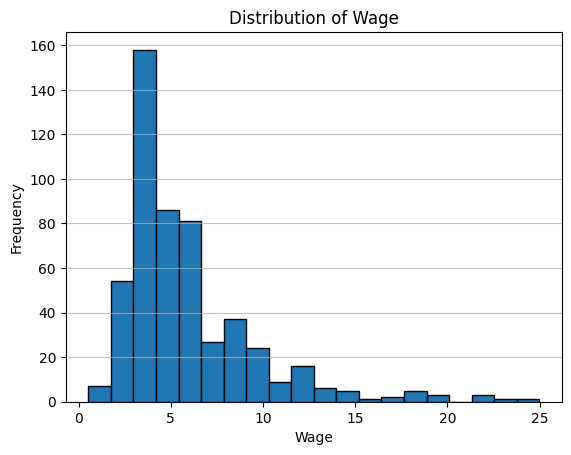

In [57]:
import matplotlib.pyplot as plt

plt.hist(wage['wage'], bins=20, edgecolor='black')
plt.title('Distribution of Wage')
plt.xlabel('Wage')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

The index_col=0 argument is to set the first column of the csv file the index of the data frame

Concise summary of a DataFrame

df.info()

In [58]:
wage.info()

<class 'pandas.core.frame.DataFrame'>
Index: 526 entries, 1 to 526
Data columns (total 24 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   wage      526 non-null    float64
 1   educ      526 non-null    int64  
 2   exper     526 non-null    int64  
 3   tenure    526 non-null    int64  
 4   nonwhite  526 non-null    int64  
 5   female    526 non-null    int64  
 6   married   526 non-null    int64  
 7   numdep    526 non-null    int64  
 8   smsa      526 non-null    int64  
 9   northcen  526 non-null    int64  
 10  south     526 non-null    int64  
 11  west      526 non-null    int64  
 12  construc  526 non-null    int64  
 13  ndurman   526 non-null    int64  
 14  trcommpu  526 non-null    int64  
 15  trade     526 non-null    int64  
 16  services  526 non-null    int64  
 17  profserv  526 non-null    int64  
 18  profocc   526 non-null    int64  
 19  clerocc   526 non-null    int64  
 20  servocc   526 non-null    int64  
 21

Descriptive statistics

df.describe

In [59]:
wage.describe()

,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,...,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
count,526.000000,526.000000,526.00000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,...,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000,526.000000
mean,5.896103,12.562738,17.01711,5.104563,0.102662,0.479087,0.608365,1.043726,0.722433,0.250951,...,0.043726,0.287072,0.100760,0.258555,0.366920,0.167300,0.140684,1.623268,473.435361,78.150190
std,3.693086,2.769022,13.57216,7.224462,0.303805,0.500038,0.488580,1.261891,0.448225,0.433973,...,0.204680,0.452826,0.301298,0.438257,0.482423,0.373599,0.348027,0.531538,616.044772,199.434664
min,0.530000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.634878,1.000000,0.000000
25%,3.330000,12.000000,5.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.202972,25.000000,0.000000
50%,4.650000,12.000000,13.50000,2.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.536867,182.500000,4.000000
75%,6.880000,14.000000,26.00000,7.000000,0.000000,1.000000,1.000000,2.000000,1.000000,0.750000,...,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.928619,676.000000,49.000000
max,24.980000,18.000000,51.00000,44.000000,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.218076,2601.000000,1936.000000


Correlation matrix

df.corr()

In [60]:
wage.corr()

,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,...,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
wage,1.000000,0.405903,0.112903,0.346890,-0.038520,-0.340098,0.228817,-0.053760,0.177885,-0.029124,...,0.055940,-0.189848,-0.141624,0.085204,0.441770,-0.140837,-0.253078,0.937062,0.030238,0.267419
educ,0.405903,1.000000,-0.299542,-0.056173,-0.084654,-0.085029,0.068881,-0.215291,0.224309,0.061372,...,0.107736,-0.059204,-0.072659,0.214198,0.496768,-0.008324,-0.163345,0.431053,-0.331256,-0.069106
exper,0.112903,-0.299542,1.000000,0.499291,0.014356,-0.041626,0.316984,-0.056319,-0.117260,0.010588,...,-0.048267,-0.104626,0.041499,-0.020599,-0.005615,-0.040385,-0.071080,0.111373,0.960971,0.422942
tenure,0.346890,-0.056173,0.499291,1.000000,0.011589,-0.197910,0.239889,-0.027037,0.000745,0.014093,...,0.063885,-0.126224,-0.062604,-0.059691,0.090624,-0.072831,-0.112679,0.325538,0.459223,0.921564
nonwhite,-0.038520,-0.084654,0.014356,0.011589,1.000000,-0.010917,-0.062259,0.077701,-0.014147,-0.080201,...,-0.072328,-0.048486,0.094866,-0.056680,-0.088552,-0.034138,-0.028769,-0.038888,0.009348,-0.007203
female,-0.340098,-0.085029,-0.041626,-0.197910,-0.010917,1.000000,-0.166128,0.033148,0.016545,0.015453,...,-0.018964,-0.053351,0.108833,0.215939,-0.177376,0.355233,0.159226,-0.373677,-0.027860,-0.175623
married,0.228817,0.068881,0.316984,0.239889,-0.062259,-0.166128,1.000000,0.154497,-0.097230,-0.011716,...,0.038239,-0.136572,-0.054906,0.064603,0.085544,0.025711,-0.157040,0.270669,0.217289,0.166822
numdep,-0.053760,-0.215291,-0.056319,-0.027037,0.077701,0.033148,0.154497,1.000000,-0.096368,-0.089640,...,-0.014791,0.047992,-0.061708,-0.072145,-0.123401,0.028897,0.055361,-0.095297,-0.130906,-0.056640
smsa,0.177885,0.224309,-0.117260,0.000745,-0.014147,0.016545,-0.097230,-0.096368,1.000000,0.055216,...,0.007973,0.017948,0.010028,0.046049,0.145965,0.107216,-0.030039,0.200124,-0.110918,0.004473
northcen,-0.029124,0.061372,0.010588,0.014093,-0.080201,0.015453,-0.011716,-0.089640,0.055216,1.000000,...,-0.059439,0.020417,-0.062645,0.068810,0.068841,-0.024479,0.043253,-0.015858,0.033540,0.009093


## 2 The OLS model

### The simple regression model
Example 2.4 (Wooldrige, 2013)

We are running the following model
\begin{align}
wage =\beta_{0}+\beta_{1}educ+u
\end{align}

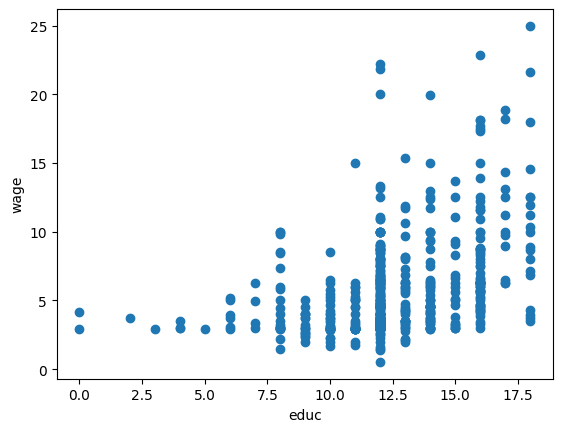

In [61]:
# Scatter plot with matplotlib

fig, ax = plt.subplots()
ax.scatter(wage["educ"], wage["wage"])
ax.set_xlabel('educ')
ax.set_ylabel('wage')
plt.show();

The way we add the constant into the regression is in the dataset.

sm.add_constant(df,prepend=False)

In [62]:
wage1 = sm.add_constant(wage, prepend=True)
wage1

,const,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,...,trcommpu,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq
1,1.0,3.10,11,2,0,0,1,0,2,1,...,0,0,0,0,0,0,0,1.131402,4,0
2,1.0,3.24,12,22,2,0,1,1,3,1,...,0,0,1,0,0,0,1,1.175573,484,4
3,1.0,3.00,11,2,0,0,0,0,2,0,...,0,1,0,0,0,0,0,1.098612,4,0
4,1.0,6.00,8,44,28,0,0,1,0,1,...,0,0,0,0,0,1,0,1.791759,1936,784
5,1.0,5.30,12,7,2,0,0,1,1,0,...,0,0,0,0,0,0,0,1.667707,49,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,1.0,15.00,16,14,2,0,1,1,2,0,...,0,0,0,1,1,0,0,2.708050,196,4
523,1.0,2.27,10,2,0,0,1,0,3,0,...,0,1,0,0,1,0,0,0.819780,4,0
524,1.0,4.67,15,13,18,0,0,1,3,0,...,0,0,0,0,1,0,0,1.541159,169,324
525,1.0,11.56,16,5,1,0,0,1,0,0,...,0,0,0,0,0,0,0,2.447551,25,1


Regarding the "prepend", if it is false, the constant will be situated as the last column of the data frame. If true, as the first column.

There are, at least, two ways to set up the data to run a regression using statsmodels. For the first one we define our dependent variable.

In [63]:
v_dep = wage["wage"]  # y = wage
v_dep

,wage
1,3.10
2,3.24
3,3.00
4,6.00
5,5.30
...,...
522,15.00
523,2.27
524,4.67
525,11.56


Defining the independent(s) variable(s)

In [64]:
 v_indep = sm.add_constant(wage["educ"], prepend=True)  # X const + educ
 v_indep

,const,educ
1,1.0,11
2,1.0,12
3,1.0,11
4,1.0,8
5,1.0,12
...,...,...
522,1.0,16
523,1.0,10
524,1.0,15
525,1.0,16


sm.OLS(y, X) Defines the model, which in this case is an OLS.

model.fit() # Make the estimation applying the fit method on the mod object.

model.fit().summary()  Show the results applying the summary method on the res object.

In [65]:
mod_1 = sm.OLS(v_dep, v_indep).fit()
print("Table 1", mod_1.summary())

Table 1                             OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     103.4
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           2.78e-22
Time:                        16:47:40   Log-Likelihood:                -1385.7
No. Observations:                 526   AIC:                             2775.
Df Residuals:                     524   BIC:                             2784.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9049      0.685     -1.321 

plot of the OLS REgression line with  datapro.plot_fit


In [66]:
print("Parameters: ", mod_1.params) #parameters of regression
print("Standard errors: ", mod_1.bse)  #std of parameters
print("Predicted values: ", mod_1.predict()) #forecast of wages


Parameters:  const   -0.904852
educ     0.541359
dtype: float64
Standard errors:  const    0.684968
educ     0.053248
dtype: float64
Predicted values:  [ 5.05010019  5.59145944  5.05010019  3.42602243  5.59145944  7.75689646
  8.83961497  5.59145944  5.59145944  8.29825572  7.75689646  6.1328187
  5.59145944  5.59145944  5.59145944  7.75689646  5.59145944  6.1328187
  5.59145944  5.59145944  5.59145944  5.59145944  7.75689646  5.59145944
  5.05010019  7.75689646  7.75689646  7.75689646  7.21553721  3.42602243
  6.67417795  6.67417795  6.1328187   5.59145944  5.59145944  7.75689646
  5.59145944  1.26058541  6.67417795  5.59145944  5.59145944  5.59145944
  6.67417795  5.05010019  6.1328187   7.21553721  4.50874093  5.59145944
  6.67417795  5.59145944  5.59145944  7.75689646  5.59145944  5.59145944
  5.59145944  7.21553721  7.75689646  3.42602243  8.83961497  7.75689646
  6.1328187   6.67417795  4.50874093  4.50874093  6.67417795  6.67417795
  7.75689646  5.59145944  7.75689646  5.5914594

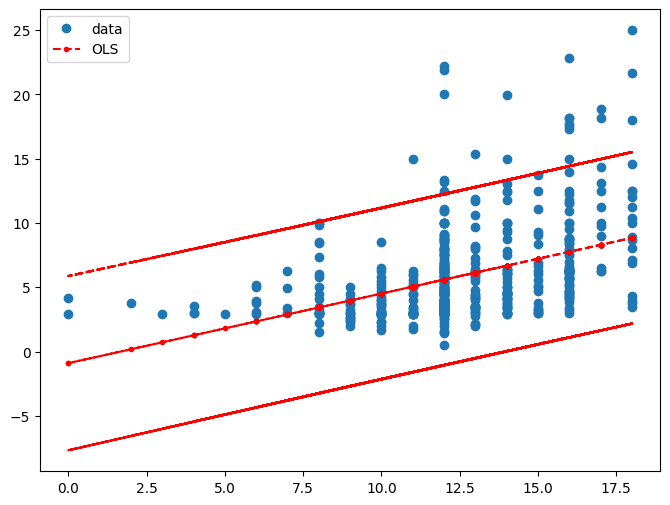

In [67]:
pred_ols = mod_1.get_prediction()
iv_l = pred_ols.summary_frame()["obs_ci_lower"]
iv_u = pred_ols.summary_frame()["obs_ci_upper"]

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(v_indep['educ'], v_dep, "o", label="data")
ax.plot(v_indep['educ'], mod_1.fittedvalues, "r--.", label="OLS")
ax.plot(v_indep['educ'], iv_u, "r--")
ax.plot(v_indep['educ'], iv_l, "r--")
ax.legend(loc="best")

Also we can get some properties on the res object, such as the number of observations. Which is also showed in Table 1, but it is convenient for future algorithms we are going to apply.

<a href="https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html#statsmodels.regression.linear_model.RegressionResults" target="_blank">See this link for other results.</a>

## **Homework**

I'll choose bla bla because...


In [68]:
v_indep1 = sm.add_constant(wage["exper"], prepend=True)  # X const + educ
v_indep1

,const,exper
1,1.0,2
2,1.0,22
3,1.0,2
4,1.0,44
5,1.0,7
...,...,...
522,1.0,14
523,1.0,2
524,1.0,13
525,1.0,5


## Multiple Regression analysis
### Determinants of College GPA Example 3.1  (Wooldrige, 2013)

First we read the gpa1 Wooldridge dataset

In [69]:
gpa1=pd.read_csv(os.path.join(econometrics_path, 'gpa1.csv'),index_col=0)
gpa1=sm.add_constant(gpa1,prepend=False)
gpa1.head()

,age,soph,junior,senior,senior5,male,campus,business,engineer,colGPA,...,car,siblings,bgfriend,clubs,skipped,alcohol,gradMI,fathcoll,mothcoll,const
1,21,0,0,1,0,0,0,1,0,3.0,...,1,1,0,0,2.0,1.0,1,0,0,1.0
2,21,0,0,1,0,0,0,1,0,3.4,...,1,0,1,1,0.0,1.0,1,1,1,1.0
3,20,0,1,0,0,0,0,1,0,3.0,...,1,1,0,1,0.0,1.0,1,1,1,1.0
4,19,1,0,0,0,1,1,1,0,3.5,...,0,1,0,0,0.0,0.0,0,0,0,1.0
5,20,0,1,0,0,0,0,1,0,3.6,...,1,1,1,0,0.0,1.5,1,1,0,1.0


In [70]:
gpa1.shape  #identify the number of observations in dataframe

(141, 30)

In [71]:
gpa1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 141 entries, 1 to 141
Data columns (total 30 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       141 non-null    int64  
 1   soph      141 non-null    int64  
 2   junior    141 non-null    int64  
 3   senior    141 non-null    int64  
 4   senior5   141 non-null    int64  
 5   male      141 non-null    int64  
 6   campus    141 non-null    int64  
 7   business  141 non-null    int64  
 8   engineer  141 non-null    int64  
 9   colGPA    141 non-null    float64
 10  hsGPA     141 non-null    float64
 11  ACT       141 non-null    int64  
 12  job19     141 non-null    int64  
 13  job20     141 non-null    int64  
 14  drive     141 non-null    int64  
 15  bike      141 non-null    int64  
 16  walk      141 non-null    int64  
 17  voluntr   141 non-null    int64  
 18  PC        141 non-null    int64  
 19  greek     141 non-null    int64  
 20  car       141 non-null    int64  
 21

In [72]:
gpa1.describe()

,age,soph,junior,senior,senior5,male,campus,business,engineer,colGPA,...,car,siblings,bgfriend,clubs,skipped,alcohol,gradMI,fathcoll,mothcoll,const
count,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,...,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.00000,141.000000,141.000000,141.0
mean,20.886525,0.021277,0.382979,0.503546,0.092199,0.524823,0.170213,0.794326,0.035461,3.056738,...,0.773050,0.936170,0.475177,0.602837,1.076241,1.901064,0.87234,0.588652,0.539007,1.0
std,1.271064,0.144819,0.487846,0.501770,0.290337,0.501164,0.377159,0.405634,0.185601,0.372310,...,0.420353,0.245321,0.501164,0.491055,1.088882,1.374701,0.33490,0.493832,0.500253,0.0
min,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.200000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.0
25%,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.800000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.00000,0.000000,0.000000,1.0
50%,21.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,...,1.000000,1.000000,0.000000,1.000000,1.000000,2.000000,1.00000,1.000000,1.000000,1.0
75%,21.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.300000,...,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.00000,1.000000,1.000000,1.0
max,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,...,1.000000,1.000000,1.000000,1.000000,5.000000,7.000000,1.00000,1.000000,1.000000,1.0


We are running the following model

\begin{align}
colGPA =\beta_{0}+\beta_{1}hsGPA+\beta_{2}ACT+u
\end{align}

In [73]:
y=gpa1["colGPA"]
y.head()

,colGPA
1,3.0
2,3.4
3,3.0
4,3.5
5,3.6


To run the regression of the example 3.1, "Determinants of College GPA," we collect only the variables:  "const", "hsGPA", and "ACT"

In [74]:
X=gpa1[["const","hsGPA","ACT"]]
X.head()

,const,hsGPA,ACT
1,1.0,3.0,21
2,1.0,3.2,24
3,1.0,3.6,26
4,1.0,3.5,27
5,1.0,3.9,28


We use the statsmodels, and remember that we define it as a short name, which is sm.

In [75]:
mod = sm.OLS(y, X) # Defines the model, which in this case is an OLS.
resgpa=mod.fit() # Make the estimation applying the fit method on the mod object.
print("Table 2",resgpa.summary())

Table 2                             OLS Regression Results                            
Dep. Variable:                 colGPA   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     14.78
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.53e-06
Time:                        16:47:40   Log-Likelihood:                -46.573
No. Observations:                 141   AIC:                             99.15
Df Residuals:                     138   BIC:                             108.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2863      0.341      3.774 

The previous model is not good according to R2, then we need to propose different independent variables. The next regression will try to improve the R2.


\begin{align}
\hat{colGPA} =1.29+0.453\ hsGPA+0.0094\ ACT
\end{align}



### Run a regression as in R
The second way to run a regression with statsmodels is like in the "lm" function in R.

smf.ols(formula='y ~ X1 + X2, data= )

In [76]:
mod_2 = smf.ols(formula ='colGPA ~ hsGPA + ACT', data= gpa1).fit()
print("Table 3",mod_2.summary())

Table 3                             OLS Regression Results                            
Dep. Variable:                 colGPA   R-squared:                       0.176
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     14.78
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.53e-06
Time:                        16:47:40   Log-Likelihood:                -46.573
No. Observations:                 141   AIC:                             99.15
Df Residuals:                     138   BIC:                             108.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.2863      0.341      3.774 

### OLS Fitted Values and Residuals
To estimate the fitted or  predicted value of the book example, we create an object z which contains the values of the variables "hs GPA" and "ACT", as well as the constant.
\begin{align}
\hat{colGPA} =1.29+0.453\ (3.5)+0.0094\ (24)\ =3.01
\end{align}

In [77]:
#z=pd.DataFrame({"const":resgpa.params[0],"hsGPA":3.5, "ACT":24},index=[0])
z=pd.DataFrame({"const":1.29,"hsGPA":3.5, "ACT":24},index=[0])
z

,const,hsGPA,ACT
0,1.29,3.5,24


In [78]:
print("Predicted values: ", mod_2.predict(z))       #Print predicted values of a specific vector

Predicted values:  0    3.099648
dtype: float64


## **Transforming a varible into log.**
# Example 3.2 Hourly Wage Equation (Wooldrige, 2013)

From now on, if we do not explain a code, es because is already explained before this notebook

In [79]:
wage1=pd.read_csv(os.path.join(econometrics_path, 'wage1.csv'),index_col=0)
wage1=sm.add_constant(wage1,prepend=False)
wage1.head()

,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,...,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq,const
1,3.10,11,2,0,0,1,0,2,1,0,...,0,0,0,0,0,0,1.131402,4,0,1.0
2,3.24,12,22,2,0,1,1,3,1,0,...,0,1,0,0,0,1,1.175573,484,4,1.0
3,3.00,11,2,0,0,0,0,2,0,0,...,1,0,0,0,0,0,1.098612,4,0,1.0
4,6.00,8,44,28,0,0,1,0,1,0,...,0,0,0,0,1,0,1.791759,1936,784,1.0
5,5.30,12,7,2,0,0,1,1,0,0,...,0,0,0,0,0,0,1.667707,49,4,1.0


We are running the following model

\begin{align}
log(wage) =\beta_{0}+\beta_{1}educ+\beta_{2}exper+\beta_{3}tenure+u
\end{align}

In [80]:
X=wage1[["const","educ","exper","tenure"]]
X.head()

,const,educ,exper,tenure
1,1.0,11,2,0
2,1.0,12,22,2
3,1.0,11,2,0
4,1.0,8,44,28
5,1.0,12,7,2


We apply log function of the numpy library to transform into log the dependent variable

np.log()

In [81]:
  wage1["lw"] = np.log(wage1["wage"]) # define it as lw
  wage1

,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,...,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq,const,lw
1,3.10,11,2,0,0,1,0,2,1,0,...,0,0,0,0,0,1.131402,4,0,1.0,1.131402
2,3.24,12,22,2,0,1,1,3,1,0,...,1,0,0,0,1,1.175573,484,4,1.0,1.175573
3,3.00,11,2,0,0,0,0,2,0,0,...,0,0,0,0,0,1.098612,4,0,1.0,1.098612
4,6.00,8,44,28,0,0,1,0,1,0,...,0,0,0,1,0,1.791759,1936,784,1.0,1.791759
5,5.30,12,7,2,0,0,1,1,0,0,...,0,0,0,0,0,1.667707,49,4,1.0,1.667707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,15.00,16,14,2,0,1,1,2,0,0,...,0,1,1,0,0,2.708050,196,4,1.0,2.708050
523,2.27,10,2,0,0,1,0,3,0,0,...,0,0,1,0,0,0.819780,4,0,1.0,0.819780
524,4.67,15,13,18,0,0,1,3,0,0,...,0,0,1,0,0,1.541159,169,324,1.0,1.541159
525,11.56,16,5,1,0,0,1,0,0,0,...,0,0,0,0,0,2.447551,25,1,1.0,2.447551


In [82]:
# In this case the dependent variable is ly
mod_3 = smf.ols(formula='lw ~ educ + exper + tenure', data=wage1)
reswage1= mod_3.fit()
print("Table 4",reswage1.summary())

Table 4                             OLS Regression Results                            
Dep. Variable:                     lw   R-squared:                       0.316
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     80.39
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           9.13e-43
Time:                        16:47:41   Log-Likelihood:                -313.55
No. Observations:                 526   AIC:                             635.1
Df Residuals:                     522   BIC:                             652.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2844      0.104      2.729 

# 3 Testing for OLS assumptions
[texto del enlace](https://)

### 3.1 Multicollinearity
Chapter 3 (Wooldrige, 2013)

In [83]:
import os
import pandas as pd
import statsmodels.api as sm

econometrics_path = '/content/drive/My Drive/econometrics/'

wage1=pd.read_csv(os.path.join(econometrics_path, 'wage1.csv'),index_col=0)
wage1=sm.add_constant(wage1,prepend=False)
wage1.head()

,wage,educ,exper,tenure,nonwhite,female,married,numdep,smsa,northcen,...,trade,services,profserv,profocc,clerocc,servocc,lwage,expersq,tenursq,const
1,3.10,11,2,0,0,1,0,2,1,0,...,0,0,0,0,0,0,1.131402,4,0,1.0
2,3.24,12,22,2,0,1,1,3,1,0,...,0,1,0,0,0,1,1.175573,484,4,1.0
3,3.00,11,2,0,0,0,0,2,0,0,...,1,0,0,0,0,0,1.098612,4,0,1.0
4,6.00,8,44,28,0,0,1,0,1,0,...,0,0,0,0,1,0,1.791759,1936,784,1.0
5,5.30,12,7,2,0,0,1,1,0,0,...,0,0,0,0,0,0,1.667707,49,4,1.0


In [84]:
# Update this path if your 'econometrics' folder is in a different location in Google Drive
econometrics_path = '/content/drive/My Drive/econometrics/'

In [85]:
import os

drive_path = '/content/drive/My Drive/econometrics/'

# Check if the directory exists
if os.path.exists(drive_path):
    print(f"Contents of {drive_path}:")
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"The directory '{drive_path}' does not exist. Please check the path.")

Contents of /content/drive/My Drive/econometrics/:
SP_Uncovering_BDAlumn_VF.xlsx
wage1.csv
gpa1.csv
hprice1.csv


In [86]:
import statsmodels.formula.api as smf
mod_4 = smf.ols(formula='lwage~educ+exper+expersq+tenure', data=wage1)
reswage2 = mod_4.fit()
print("Table 5",reswage2.summary())

Table 5                             OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.355
Method:                 Least Squares   F-statistic:                     73.09
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           3.81e-49
Time:                        16:47:41   Log-Likelihood:                -296.29
No. Observations:                 526   AIC:                             602.6
Df Residuals:                     521   BIC:                             623.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1983      0.102      1.945 

In [87]:
import os

# List contents of 'My Drive' to help locate the 'econometrics' folder
print("Contents of '/content/drive/My Drive/':")
for item in os.listdir('/content/drive/My Drive/'):
    print(item)


Contents of '/content/drive/My Drive/':
linear_regression_v3.ipynb
Classroom
Presentación sin título (3).gslides
Trabajo de mate.gslides
A01751815_PRESENTACIÓN.gslides
Documento sin título (76).gdoc
English homework.gdoc
Arte.gslides
Copia de tarea.gdoc
Copia de Evaluación de Fuentes.gdoc
Copia de Ensayo inglés.gdoc
Actividad 2 - Autorretrato.gdoc
Copy of CERTIFICADO MÉDICO (Bienestar Integral II).pdf
Untitled document (6).gdoc
A01751815_Caracteristica_Vida_Santiago Alejandro Lucio.gslides
Documento sin título (75).gdoc
Copia de COCA-COLA.gslides
Tareita.gdoc
Preguntas de investigación.gdoc
Proyecto Eje.gslides
MEMES.gslides
Pregunta de Investigación y Análisis de Fuentes.gdoc
Desarrollo de la Revolución Francesa y la Independencia de los Estados Unidos como ejemplos de Revoluciones liberales.gslides
Tarea TikTok.gdoc
Documento sin título (74).gdoc
INFOGRAPHIC: Gross Vintage Hygiene Practices:.gdoc
Tutoreo1 (1).jpeg
Copia de Liberales y conservadores (1).gslides
Copia de L

Please examine the output above to confirm if the 'econometrics' folder is present and to identify its exact path. If it's nested within another folder, you'll need to update the `econometrics_path` variable accordingly.

The first clue of Multicollinearity in the regression output is the message; "The condition number is large,n. This might indicate that there are strong multicollinearity or other numerical problems."

Regarding the No Perfect Collinearity assumption, Wooldridge (2013) explain the VIF indicator. We could ue the variance_inflation_factor method from sms directly, however, first we have to create the subset with independent variables, then do it one by one.

In [88]:
x1=wage1.loc[:,("const","educ","exper","expersq","tenure")]
x1.head()

,const,educ,exper,expersq,tenure
1,1.0,11,2,4,0
2,1.0,12,22,484,2
3,1.0,11,2,4,0
4,1.0,8,44,1936,28
5,1.0,12,7,49,2


Another way to identify a specific type of multicolinearity is using correlation matrix of independent variables, as we ask now:

In [89]:
x1.corr()

,const,educ,exper,expersq,tenure
const,NaN,NaN,NaN,NaN,NaN
educ,NaN,1.000000,-0.299542,-0.331256,-0.056173
exper,NaN,-0.299542,1.000000,0.960971,0.499291
expersq,NaN,-0.331256,0.960971,1.000000,0.459223
tenure,NaN,-0.056173,0.499291,0.459223,1.000000


A specific tool for correlations is a heapmap, that can be easier to understand

<Axes: >

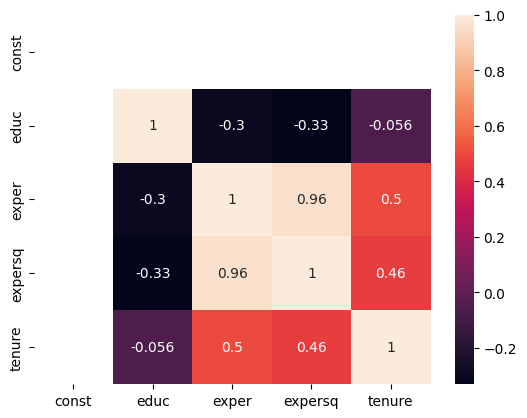

In [90]:
import seaborn as sns
sns.heatmap(x1.corr(), annot=True)

Then, we ask for VIF calculation acording to the next steps:

In [91]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["variable"] = x1.columns

# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(x1.values, i)
                          for i in range(len(x1.columns))]

print(vif_data)

  variable        VIF
0    const  29.982772
1     educ   1.140644
2    exper  13.866460
3  expersq  13.492686
4   tenure   1.355685


Sometimes the VIF value 10 is chosen: if VIFj is above 10 (equivalently, R2j is above .9), then we conclude that multicollinearity is a “problem” for estimating. But a VIFj above 10 does not mean that the standard deviation of a coefficient is too large to be useful because the standard deviation also depends on sigma and SSTj, and the latter can be increased by increasing the sample size.
In this case, we can decide if we takeout exp or exp2.

In [92]:
x1=wage1.loc[:,("const","educ","exper","tenure")]
x1.head()
vif_data = pd.DataFrame()
vif_data["variable"] = x1.columns
vif_data["VIF"] = [variance_inflation_factor(x1.values, i)
                          for i in range(len(x1.columns))]
print(vif_data)

  variable        VIF
0    const  29.378903
1     educ   1.112771
2    exper   1.477618
3   tenure   1.349296



Once we found that multicoliearity is not present, we can run our regression again:

In [93]:
mod_5 = smf.ols(formula='lwage~educ+exper+tenure', data=wage1)
reswage3 = mod_5.fit()
print("Table 6",reswage3.summary())

Table 6                             OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.316
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     80.39
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           9.13e-43
Time:                        16:47:42   Log-Likelihood:                -313.55
No. Observations:                 526   AIC:                             635.1
Df Residuals:                     522   BIC:                             652.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2844      0.104      2.729 

### 3.2 Heterokedasticity

**Asumption 5. MLR 5. Homoskedasticity**
An important asumption of the OLS model is Homoskedasticity:

\begin{align}
Var (u_i/X) = \sigma^2
\end{align}


Heterokedasticity is then characterized as:

\begin{align}
Var (u_i/X) = \sigma_i^2
\end{align}


3.2.1 The Breusch-Pagan Test for Heteroskedasticity:


In [96]:
hprice1=pd.read_csv(os.path.join(econometrics_path, 'hprice1.csv'),index_col=0)
hprice1=sm.add_constant(hprice1,prepend=False)
hprice1.head()

,price,assess,bdrms,lotsize,sqrft,colonial,lprice,lassess,llotsize,lsqrft,const
1,300.0,349.100006,4,6126,2438,1,5.703783,5.855359,8.720297,7.798934,1.0
2,370.0,351.500000,3,9903,2076,1,5.913503,5.862210,9.200593,7.638198,1.0
3,191.0,217.699997,3,5200,1374,0,5.252274,5.383118,8.556414,7.225482,1.0
4,195.0,231.800003,3,4600,1448,1,5.273000,5.445875,8.433811,7.277938,1.0
5,373.0,319.100006,4,6095,2514,1,5.921578,5.765504,8.715224,7.829630,1.0


Regression equation is proposed as:

\begin{align}
price =\beta_{0}+\beta_{1}lotsize+\beta_{2}sqrft+\beta_{3}bdrms+u
\end{align}

where:
*   *price* is the price of house
*   *lotsize* is the size of the land
*   *sqrft* is the size of building
*   *bdrms* is the number of bedrooms.



In [97]:
mod = smf.ols(formula='price ~  lotsize+sqrft+bdrms', data=hprice1)
#rescimr1 = mod.fit(cov_type='nonrobust')
res_ols = mod.fit()
#res_ols = mod.fit(cov_type='HC1')
print("Table 7",res_ols.summary())

Table 7                             OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.672
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     57.46
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           2.70e-20
Time:                        16:48:22   Log-Likelihood:                -482.88
No. Observations:                  88   AIC:                             973.8
Df Residuals:                      84   BIC:                             983.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -21.7703     29.475     -0.739 

For testing heterokedasticity, we can use Breusch Pagan test, that works in the next way:

\begin{align}
H_0: \text{residuals are uniformly scattered. (No heteroskedasticity} \\ H_a: \text{residuals are not uniformly scattered. (No heteroskedasticity)}
\end{align}

Heterokedasticity must be performed as F-test using the next regression
\begin{align}
u_i^2 = \gamma_0 + \gamma_1 x + \epsilon_i
\end{align}

So, Breush Pagan test is made in the next step:

In [98]:
from statsmodels.compat import lzip
keys = ['Lagrange Multiplier statistic:', 'LM test\'s p-value:', 'F-statistic:', 'F-test\'s p-value:']
results=sms.het_breuschpagan(res_ols.resid, res_ols.model.exog)
lzip(keys, results)


[('Lagrange Multiplier statistic:', np.float64(14.092385504350183)),
 ("LM test's p-value:", np.float64(0.0027820595556891643)),
 ('F-statistic:', np.float64(5.338919363241392)),
 ("F-test's p-value:", np.float64(0.00204774442093613))]

Rememer that, if the p-value is sufficiently small, that is below the chosen significance level, then we reject the null hypothesis of homoskedasticity.

The second test for heterokedasticity is White Test, that is very popular. Hipothesis are the same for White, but the regression used is different:

\begin{align}
u_i^2 = \gamma_0 + \gamma_1 x^2 + \epsilon_i
\end{align}


In [99]:
from statsmodels.stats.diagnostic import het_white
white_test = het_white(res_ols.resid, res_ols.model.exog)
labels = ['Test Statistic', 'Test Statistic p-value', 'F-Statistic', 'F-Test p-value']
lzip(labels, white_test)

[('Test Statistic', np.float64(33.731657711098315)),
 ('Test Statistic p-value', np.float64(9.952939773734474e-05)),
 ('F-Statistic', np.float64(5.386953445894578)),
 ('F-Test p-value', np.float64(1.0129388323901178e-05))]

To correct, we change the model to logs of price, lotsize and sqrft, bedrooms remain in the same way.

In [100]:
mod1 = smf.ols(formula='lprice ~  llotsize+lsqrft+bdrms', data=hprice1)
#rescimr1 = mod.fit(cov_type='nonrobust')
res_ols1 = mod1.fit()
print("Table 8",res_ols1.summary())

Table 8                             OLS Regression Results                            
Dep. Variable:                 lprice   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     50.42
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           9.74e-19
Time:                        16:48:44   Log-Likelihood:                 25.861
No. Observations:                  88   AIC:                            -43.72
Df Residuals:                      84   BIC:                            -33.81
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.2970      0.651     -1.992 

We check again presence of heterokedasticity



In [101]:
from statsmodels.compat import lzip
keys = ['Lagrange Multiplier statistic:', 'LM test\'s p-value:', 'F-statistic:', 'F-test\'s p-value:']
results=sms.het_breuschpagan(res_ols1.resid, res_ols1.model.exog)
lzip(keys, results)

[('Lagrange Multiplier statistic:', np.float64(4.223248117304391)),
 ("LM test's p-value:", np.float64(0.2383445905811842)),
 ('F-statistic:', np.float64(1.4115007400871578)),
 ("F-test's p-value:", np.float64(0.24514541735245046))]

Heterokedasticity is now it is corrected.

# 4 Autocorrelation



Asumption 6. Autocorrelation is a condition that estabishes that residuals are not correlated among them, that is,

\begin{align}
corr(u_i,u_{i-j}) = 0 \\ \forall i,j
\end{align}


Autocorrelation of first order is tested by Durbin Watson test, but for higher order test used is Breusch-Godfrey. Durbin Watson is evaluated in all regressions, we can see this output in last regression.


In [102]:
mod1 = smf.ols(formula='lprice ~  llotsize + lsqrft+bdrms', data=hprice1)
#rescimr1 = mod.fit(cov_type='nonrobust')
res_ols2 = mod1.fit()
print("Table 8",res_ols1.summary())

Table 8                             OLS Regression Results                            
Dep. Variable:                 lprice   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     50.42
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           9.74e-19
Time:                        16:48:50   Log-Likelihood:                 25.861
No. Observations:                  88   AIC:                            -43.72
Df Residuals:                      84   BIC:                            -33.81
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.2970      0.651     -1.992 

In this case, DW is 2.089, very close to 2, the central value.


\begin{align}
H_0: \text{residuals are not correlated} \\ H_a: \text{residuals are autocorrelated}
\end{align}


To test Breusch Godfrey procedure, we then run in the next way:

In [103]:
import statsmodels.stats.diagnostic as dg
results2= dg.acorr_breusch_godfrey(res_ols2, nlags=3) #perform Breusch-Godfrey test at order p = 3

keys = ['X2 statistic:', ' p-value:', 'F-statistic:', ' p-value:']
lzip(keys, results2)

[('X2 statistic:', np.float64(5.005865170989562)),
 (' p-value:', np.float64(0.17136817110857452)),
 ('F-statistic:', 1.6285290508200367),
 (' p-value:', 0.18920148566347395)]

If autocorrelation needs to be corrected, then we apply Cochrane-Orcutt procedure, but it depends on the degree of the autocorrelation.

We will use lags of dependent and independent variables with correlation coeficient of residuals:

In [104]:
# LAG 0
res_ids1 =res_ols1.resid[1:len(res_ols1.resid)]

# LAG 1
res_ids2 = res_ols1.resid[0:len(res_ols1.resid)-1]

# calculate correlation coef. for lag 1
rho= np.corrcoef(res_ids1,res_ids2)[0,1]

# Cochrane-Orcutt equation
a = len(hprice1['lprice'])
hprice1["xlprice"] = hprice1['lprice'][1:a] - rho * hprice1['lprice'][0:a-1]

hprice1["xllotsize"] = hprice1['llotsize'][1:a] - rho*hprice1['llotsize'][0:a-1]
hprice1["xlsqrft"] = hprice1['lsqrft'][1:a] - rho*hprice1['lsqrft'][0:a-1]
hprice1["xbdrms"] = hprice1['bdrms'][1:a] - rho*hprice1['bdrms'][0:a-1]

mod11 = smf.ols(formula='xlprice ~  xllotsize + xlsqrft + xbdrms', data=hprice1)
#rescimr1 = mod.fit(cov_type='nonrobust')
res_ols3 = mod11.fit()
print("Table 9",res_ols3.summary())

Table 9                             OLS Regression Results                            
Dep. Variable:                xlprice   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     49.15
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           2.81e-18
Time:                        16:48:53   Log-Likelihood:                 20.543
No. Observations:                  86   AIC:                            -33.09
Df Residuals:                      82   BIC:                            -23.27
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.3631      0.692     -1.968 

We can see that DW statistic changed, getting closer to 0. Then seems like autocorrelation is being improved.
We then run again Breush Godfrey test again and compare the results:


In [105]:
results3= dg.acorr_breusch_godfrey(res_ols3, nlags=3) #perform Breusch-Godfrey test at order p = 3
keys = ['X2 statistic:', ' p-value:', 'F-statistic:', ' p-value:']
lzip(keys, results3)

[('X2 statistic:', np.float64(4.685747296849316)),
 (' p-value:', np.float64(0.19630848777332827)),
 ('F-statistic:', 1.5174627003479515),
 (' p-value:', 0.21644949664483995)]